In [1]:
import pickle
from matplotlib import pyplot as plt
from matplotlib.axes import Axes
from collections import Counter
import numpy as np
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator, FixedLocator, NullLocator)
from typing import Optional

from qiskit_qaoa.utils.hamiltonian_utils import get_Q_and_hamiltonian
from qiskit_qaoa.utils.string_utils import evaluate_sparse_pauli_samples

In [ ]:
def plot_several_p_dist(
    axs: list[Axes], 
    filename, prob,
    db_fixed, dg_fixed, shots,
    ps, rescale,
    max_beta_T:Optional[float]=None, eps:Optional[float]=None, alpha:Optional[float]=None, 
    simulation:Optional[bool]=None, error_mitigation:Optional[bool]=None,
    backend:Optional[str]=None,
    iters=None, normalise=False
) -> list[Axes]:
    data_file = f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/qubo_data/qubo_data_{filename}.gfa.pkl'

    _, hamiltonian, _, ising_offset = get_Q_and_hamiltonian(data_file)
    num_qubits: int = hamiltonian.num_qubits

    base_file_name = f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/nonvariational/hardware/hardware.{filename}'
    append_str = (".error_mit" if error_mitigation else "")+(f".backend{backend}" if backend else "") + (f'{".simulation" if simulation else ""}') + (f'.db{db_fixed}.dg{dg_fixed}.shots{shots}') + (f'.betaT{max_beta_T}' if max_beta_T is not None else '') + (f'.eps{eps}' if eps is not None else '') + (f'.alpha{alpha}' if alpha is not None else '')
    with open(f'{base_file_name}{append_str}.pkl', 'rb') as f:
        res = pickle.load(f)
        
    sample_sequence = []
    samples_dict: dict[tuple[int, float], list[list[str]]] = res['samples_dict']
    keys = samples_dict.keys()
    energies = res['energies']
    if iters is None:
        iters = [0, 5, 9]
    energies = np.array(energies)
    if normalise:
        energies /= energies.max()
        # energies /= energies[0,0]
    
    cutoff = 25
    ax = axs[0]
    rand_shots = min(shots*10, 40000)
    random_samples = np.random.choice(('0', '1'), (rand_shots, num_qubits), p=(1-prob,prob))
    rand_samples = [''.join(sample) for sample in random_samples]
    rand_vals = np.round(ising_offset + evaluate_sparse_pauli_samples(rand_samples, hamiltonian), 2)
    ax.hist(rand_vals, bins=range(cutoff+1), weights=[1/rand_shots]*len(rand_vals), rwidth=1, log=True, color='gray', label='Random')
    ax.set_xlim(0, cutoff)
    ax.set_ylim(10**-3, 10**0)
    

    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.xaxis.set_minor_locator(AutoMinorLocator(10))
    ax.text(.95, .99, 'Iter = 0', ha='right', va='top', transform=ax.transAxes)
    # ax.legend(loc='best', bbox_to_anchor=(0.6, 0.6, 0.4, 0.4))
    ax.legend(
        loc="upper right",
        bbox_to_anchor=(1.0, 0.92),  # move legend down
        frameon=True
    )
    
    for i in range(1, len(axs)):
        ax = axs[i]
        sample_sequence = []
        for p in ps:
            rescale_value = None
            for key in keys:
                if key[0] == p and np.abs(key[1] - rescale)**2 < 0.0005:
                    rescale_value = key[1]
                    break
            if rescale_value is None:
                raise Exception('Could not rescale value')
            if len(samples_dict[(p, rescale_value)]) > 3:
                counter = Counter(samples_dict[(p, rescale_value)][iters[i-1]])
            else:
                counter = Counter(samples_dict[(p, rescale_value)][i-1])
            if i == len(axs) - 1:
                print(p, counter.most_common(2))
            evals = np.round(ising_offset + evaluate_sparse_pauli_samples(list(counter.keys()), hamiltonian), 2)
            
            # energies = [count * [evals[idx]] for idx, count in enumerate(counter.values()) if evals[idx] < cutoff]
            energies = [count * [evals[idx]] for idx, count in enumerate(counter.values())]
            sample_vals = np.array([x for xs in energies for x in xs])
            # if alpha is not None:
            #     sample_vals = np.sort(sample_vals)[:int(alpha * len(sample_vals))]
            sample_sequence.append(sample_vals)

        ax.hist(sample_sequence, bins=range(cutoff+1), weights=[[1/len(sample_vals)]*len(sample_vals) for sample_vals in sample_sequence], rwidth=1, log=True, label=ps)
        ax.set_xlim(0, cutoff)
        ax.set_ylim(10**-3, 10**0)

        ax.xaxis.set_major_locator(MultipleLocator(10))
        ax.xaxis.set_minor_locator(AutoMinorLocator(10))
        ax.tick_params(axis='x', which='major', length=6)
        ax.tick_params(axis='x', which='minor', length=2)
        ax.text(.95, .99, f'Iter = {iters[i-1]+1}', ha='right', va='top', transform=ax.transAxes)
          
    # ax.legend(loc='best', bbox_to_anchor=(0.6, 0.6, 0.4, 0.4))
    ax.legend(
        loc="upper right",
        bbox_to_anchor=(1.0, 0.92),  # move legend down
        frameon=True
    )
    return axs




In [ ]:
delta_b_fixed = 0.63
delta_g_fixed = 0.16
rescale = 10**(0.0)

n = 4000
ps = [1,3,5]
iters=range(5)
max_beta_T = 0.15
eps = 0.15
alpha = 0.1
# ENERGIES ** 2

fig, axs = plt.subplots(2, len(iters) + 1, sharey='row', sharex='col')
axs0 = axs[0, :]
# axs1 = axs[1, :]
# axs2 = axs[2, :]
# axs3 = axs[3, :]
# axs4 = axs[4, :]

plot_several_p_dist(axs0, 'test_N2_W2', (2*2)**-1, delta_b_fixed, delta_g_fixed, n, ps, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, simulation=True)

for ax in axs[:, 0]:
    ax.set_ylabel(r'Sample density')
    
qubits = [8,18]
for idx, ax in enumerate(axs[:, -1]):
    twin = ax.twinx()
    twin.set_yticks([])
    twin.set_ylabel(f'{qubits[idx]} qubits')
    
for ax in axs[-1, :]:  
    ax.set_xlabel(r'Energy')  
    
fig.suptitle(f'$\\Delta_\\beta = {delta_b_fixed}, \\Delta_\\gamma = {delta_g_fixed}, p = 1,3,5, n = 4000, Simulation$', fontsize=16)
fig.set_figheight(3 * len(axs[:, 0]))
fig.set_figwidth(3.5 * len(axs[0, :]))
plt.tight_layout()

In [ ]:
delta_b_fixed = 0.63
delta_g_fixed = 0.16
rescale = 10**(0.0)

n = 40000
ps = [1,3]
iters=range(5)
max_beta_T = 0.15
eps = 0.15
alpha = 0.1
# ENERGIES ** 2

fig, axs = plt.subplots(2, len(iters) + 1, sharey='row', sharex='col')
axs0 = axs[0, :]
axs1 = axs[1, :]
# axs2 = axs[2, :]
# axs3 = axs[3, :]
# axs4 = axs[4, :]

plot_several_p_dist(axs0, 'test_N2_W2', (2*2)**-1, delta_b_fixed, delta_g_fixed, n, ps, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, error_mitigation=True)
plot_several_p_dist(axs1, 'trivial', (2*3)**-1, delta_b_fixed, delta_g_fixed, n, ps, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, error_mitigation=True, backend="ibm_boston")


for ax in axs[:, 0]:
    ax.set_ylabel(r'Sample density')
    
qubits = [8,18]
for idx, ax in enumerate(axs[:, -1]):
    twin = ax.twinx()
    twin.set_yticks([])
    twin.set_ylabel(f'{qubits[idx]} qubits')
    
for ax in axs[-1, :]:  
    ax.set_xlabel(r'Energy')  
    
fig.suptitle(f'$\\Delta_\\beta = {delta_b_fixed}, \\Delta_\\gamma = {delta_g_fixed}, p = 1,3,5, n = 4000$, Hardware', fontsize=16)
fig.set_figheight(3 * len(axs[:, 0]))
fig.set_figwidth(3.5 * len(axs[0, :]))
plt.tight_layout()

In [ ]:
delta_b_fixed = 0.63
delta_g_fixed = 0.16
rescale = 10**(0.0)

n = 40000
ps = [1,3]
iters=range(10)
max_beta_T = 0.15
eps = 0.15
alpha = 0.1
# ENERGIES ** 2

fig, axs = plt.subplots(2, len(iters) + 1, sharey='row', sharex='col')
axs0 = axs[0, :]
axs1 = axs[1, :]
# axs2 = axs[2, :]
# axs3 = axs[3, :]
# axs4 = axs[4, :]

# plot_several_p_dist(axs0, 'test_N2_W2', (2*2)**-1, delta_b_fixed, delta_g_fixed, n, ps, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, error_mitigation=True)
plot_several_p_dist(axs1, 'trivial', (2*3)**-1, delta_b_fixed, delta_g_fixed, n, ps, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, error_mitigation=True, backend="ibm_boston")


for ax in axs[:, 0]:
    ax.set_ylabel(r'Sample density')
    
qubits = [8,18]
for idx, ax in enumerate(axs[:, -1]):
    twin = ax.twinx()
    twin.set_yticks([])
    twin.set_ylabel(f'{qubits[idx]} qubits')
    
for ax in axs[-1, :]:  
    ax.set_xlabel(r'Energy')  
    
fig.suptitle(f'$\\Delta_\\beta = {delta_b_fixed}, \\Delta_\\gamma = {delta_g_fixed}, p = 1,3,5, n = 4000$, Hardware', fontsize=16)
fig.set_figheight(3 * len(axs[:, 0]))
fig.set_figwidth(3.5 * len(axs[0, :]))
plt.tight_layout()

In [2]:
def compare_hardware_and_noiseless(
    axs: list[Axes], 
    filename, prob,
    db_fixed, dg_fixed, shots,
    p, rescale,
    max_beta_T:Optional[float]=None, eps:Optional[float]=None, alpha:Optional[float]=None, 
    error_mitigation:Optional[bool]=None, backend:Optional[str]=None,
    iters=None
) -> list[Axes]:
    data_file = f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/qubo_data/qubo_data_{filename}.gfa.pkl'

    _, hamiltonian, _, ising_offset = get_Q_and_hamiltonian(data_file)
    num_qubits: int = hamiltonian.num_qubits

    base_file_name = f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/nonvariational/hardware/hardware.{filename}'
    append_str = (".error_mit" if error_mitigation else "")+(f".backend{backend}" if backend else "") + (f'.db{db_fixed}.dg{dg_fixed}.shots{shots}') + (f'.betaT{max_beta_T}' if max_beta_T is not None else '') + (f'.eps{eps}' if eps is not None else '') + (f'.alpha{alpha}' if alpha is not None else '')
    with open(f'{base_file_name}{append_str}.pkl', 'rb') as f:
        res = pickle.load(f)

    base_file_name = f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/nonvariational/nonvariational.{filename}.db{db_fixed}.dg{dg_fixed}.shots{int(shots*alpha)}'
    append_str = (f'.betaT{max_beta_T}' if max_beta_T is not None else '') + (f'.eps{eps}' if eps is not None else '') + (f'.alpha1.0' if alpha is not None else '')
    with open(f'{base_file_name}{append_str}.pkl', 'rb') as f:
        simulation_res = pickle.load(f)
        
    sample_sequence = []

    # samples_dict: dict[tuple[int, float], list[list[str]]] = res['samples_dict']
    # simulation_samples_dict: dict[tuple[int, float], list[list[str]]] = simulation_res['samples_dict']
    samples_dicts = {
        'hardware': res['samples_dict'],
        'simulation': simulation_res['samples_dict']
    }

    if iters is None:
        iters = [0, 5, 9]
    
    cutoff = 25
    ax = axs[0]
    rand_shots = min(shots*10, 40000)
    random_samples = np.random.choice(('0', '1'), (rand_shots, num_qubits), p=(1-prob,prob))
    rand_samples = [''.join(sample) for sample in random_samples]
    rand_vals = np.round(ising_offset + evaluate_sparse_pauli_samples(rand_samples, hamiltonian), 2)
    ax.hist(rand_vals, bins=range(cutoff+1), weights=[1/rand_shots]*len(rand_vals), rwidth=1, log=True, color='gray', label='Random')
    ax.set_xlim(0, cutoff)
    ax.set_ylim(1/shots, 10**0)
    

    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.xaxis.set_minor_locator(AutoMinorLocator(10))
    ax.text(.95, .99, 'Iter = 0', ha='right', va='top', transform=ax.transAxes)
    # ax.legend(loc='best', bbox_to_anchor=(0.6, 0.6, 0.4, 0.4))
    ax.legend(
        loc="upper right",
        bbox_to_anchor=(1.0, 0.92),  # move legend down
        frameon=True
    )
    
    for i in range(1, len(axs)):
        ax = axs[i]
        sample_sequence = []
        for name in samples_dicts.keys():
            rescale_value = None
            for key in samples_dicts[name].keys():
                if key[0] == p and np.abs(key[1] - rescale)**2 < 0.0005:
                    rescale_value = key[1]
                    break
            if rescale_value is None:
                raise Exception('Could not rescale value')
            try:
                if len(samples_dicts[name][(p, rescale_value)]) > 3:
                    counter = Counter(samples_dicts[name][(p, rescale_value)][iters[i-1]])
                else:
                    counter = Counter(samples_dicts[name][(p, rescale_value)][i-1])
                if i == len(axs) - 1:
                    print(p, counter.most_common(2))
                evals = np.round(ising_offset + evaluate_sparse_pauli_samples(list(counter.keys()), hamiltonian), 2)
                
                energies = [count * [evals[idx]] for idx, count in enumerate(counter.values())]
                sample_vals = np.array([x for xs in energies for x in xs])
                if name == 'simulation':
                    sample_sequence.append(sample_vals)
                if alpha is not None and name == 'hardware':
                    quasi_sample_vals = np.sort(sample_vals)[:int(alpha * len(sample_vals))]
                    sample_sequence.append(quasi_sample_vals)
            except:
                pass
            

        ax.hist(
            sample_sequence, 
            bins=range(cutoff+1), 
            weights=[[1/len(sample_vals)]*len(sample_vals) for sample_vals in sample_sequence], 
            rwidth=1, 
            log=True, 
            label=['E-M Hardware', 'Simulation']
            # label=['Hardware', 'Simulation'] if alpha is None else ['Hardware', 'E-M Hardware', 'Simulation']
        )
        ax.set_xlim(0, cutoff)
        ax.set_ylim(1/shots, 10**0)

        ax.xaxis.set_major_locator(MultipleLocator(10))
        ax.xaxis.set_minor_locator(AutoMinorLocator(10))
        ax.tick_params(axis='x', which='major', length=6)
        ax.tick_params(axis='x', which='minor', length=2)
        ax.text(.95, .99, f'Iter = {iters[i-1]+1}', ha='right', va='top', transform=ax.transAxes)
          
    # ax.legend(loc='best', bbox_to_anchor=(0.6, 0.6, 0.4, 0.4))
    ax.legend(
        loc="upper right",
        bbox_to_anchor=(1.0, 0.92),  # move legend down
        frameon=True
    )
    return axs




1 [('000001100000000100000001', 12), ('000001100000000000000001', 8)]
1 [('000010001000010000000001', 10), ('000010001000000010001000', 9)]
1 [('0100000000000000000000000001', 10), ('0100000000010000000000000001', 5)]
1 [('0100000000000000000000000001', 368), ('0000000000000000000000000001', 37)]


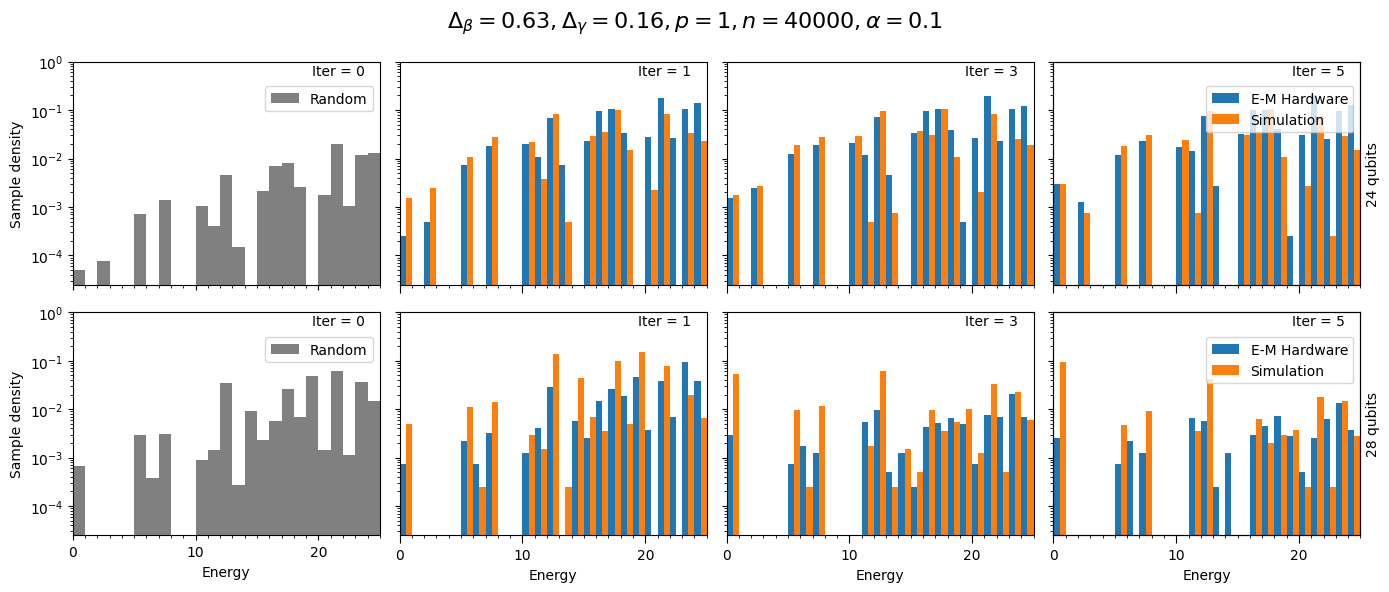

In [4]:
delta_b_fixed = 0.63
delta_g_fixed = 0.16
rescale = 10**(0.0)

n = 40000
iters=[0,2,4]
max_beta_T = 0.15
eps = 0.15
alpha = 0.1
p = 1
# ENERGIES ** 2

fig, axs = plt.subplots(2, len(iters) + 1, sharey='row', sharex='col')
axs0 = axs[0, :]
axs1 = axs[1, :]
# axs2 = axs[2, :]
# axs3 = axs[3, :]
# axs4 = axs[4, :]

# compare_hardware_and_noiseless(axs0, 'test_N2_W2', (2*2)**-1, delta_b_fixed, delta_g_fixed, n, p, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, error_mitigation=True)
# compare_hardware_and_noiseless(axs1, 'trivial',    (2*3)**-1, delta_b_fixed, delta_g_fixed, n, p, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, error_mitigation=True, backend="ibm_boston")
compare_hardware_and_noiseless(axs0, 'test_N3_W4', (2*3)**-1, delta_b_fixed, delta_g_fixed, n, p, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, error_mitigation=True, backend="ibm_boston")
compare_hardware_and_noiseless(axs1, 'test_N7_W2', (2*7)**-1, delta_b_fixed, delta_g_fixed, n, p, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, error_mitigation=True, backend="ibm_boston")
# compare_hardware_and_noiseless(axs4, 'test_N4_W5', (2*4)**-1, delta_b_fixed, delta_g_fixed, n, p, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, error_mitigation=True, backend="ibm_boston")


for ax in axs[:, 0]:
    ax.set_ylabel(r'Sample density')
    
# qubits = [8,18,24, 28, 40]
qubits = [24, 28]
for idx, ax in enumerate(axs[:, -1]):
    twin = ax.twinx()
    twin.set_yticks([])
    twin.set_ylabel(f'{qubits[idx]} qubits')
    
for ax in axs[-1, :]:  
    ax.set_xlabel(r'Energy')  
    
fig.suptitle(f'$\\Delta_\\beta = {delta_b_fixed}, \\Delta_\\gamma = {delta_g_fixed}, p = {p}, n = {n}, \\alpha = {alpha}$', fontsize=16)
fig.set_figheight(3 * len(axs[:, 0]))
fig.set_figwidth(3.5 * len(axs[0, :]))
plt.tight_layout()

figname = f'/nfs/users/nfs_j/jc59/quantumwork/pangenome/new_qubo_formulation/out/nonvariational_hardware.db{np.round(delta_b_fixed, 2)}.dg{np.round(delta_g_fixed,2)}.p{p}.png'
fig.savefig(figname, dpi=200, bbox_inches='tight')
plt.show()


In [ ]:
delta_b_fixed = 0.63
delta_g_fixed = 0.16
rescale = 10**(0.0)

n = 40000
iters=range(0,10,2)
max_beta_T = 0.15
eps = 0.15
alpha = 0.1
p = 1
# ENERGIES ** 2

fig, axs = plt.subplots(5, len(iters) + 1, sharey='row', sharex='col')
axs0 = axs[0, :]
axs1 = axs[1, :]
axs2 = axs[2, :]
axs3 = axs[3, :]
axs4 = axs[4, :]

compare_hardware_and_noiseless(axs0, 'test_N2_W2', (2*2)**-1, delta_b_fixed, delta_g_fixed, n, p, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, error_mitigation=True)
compare_hardware_and_noiseless(axs1, 'trivial',    (2*3)**-1, delta_b_fixed, delta_g_fixed, n, p, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, error_mitigation=True, backend="ibm_boston")
compare_hardware_and_noiseless(axs2, 'test_N3_W4', (2*3)**-1, delta_b_fixed, delta_g_fixed, n, p, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, error_mitigation=True, backend="ibm_boston")
compare_hardware_and_noiseless(axs3, 'test_N7_W2', (2*7)**-1, delta_b_fixed, delta_g_fixed, n, p, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, error_mitigation=True, backend="ibm_boston")
compare_hardware_and_noiseless(axs4, 'test_N4_W5', (2*4)**-1, delta_b_fixed, delta_g_fixed, n, p, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, error_mitigation=True, backend="ibm_boston")


for ax in axs[:, 0]:
    ax.set_ylabel(r'Sample density')
    
qubits = [8,18,24, 28, 40]
for idx, ax in enumerate(axs[:, -1]):
    twin = ax.twinx()
    twin.set_yticks([])
    twin.set_ylabel(f'{qubits[idx]} qubits')
    
for ax in axs[-1, :]:  
    ax.set_xlabel(r'Energy')  
    
fig.suptitle(f'$\\Delta_\\beta = {delta_b_fixed}, \\Delta_\\gamma = {delta_g_fixed}, p = {p}, n = {n}, \\alpha = {alpha}$', fontsize=16)
fig.set_figheight(3 * len(axs[:, 0]))
fig.set_figwidth(3.5 * len(axs[0, :]))
plt.tight_layout()

1 [('1000000000010000000001000000000100100000', 3), ('0100000000000001001000000000000100100000', 3)]
1 [('0000100000010000000000100000100000010000', 50), ('0000100000010000000000100000100000000001', 25)]
1 [('001011011100101001010110110101000110000100001101', 1), ('001001000000100011100011000000100100101100001111', 1)]
1 [('000001000000100000010000000000100000100010000000', 32), ('000001000000000100010000000000100000100010000000', 30)]
1 [('111001000000100000000000000000100000100010000000', 2), ('000000100000110000010000000011100000100010000000', 2)]
1 [('000001000000100000010000000000100000100010000000', 32), ('000001000000000100010000000000100000100010000000', 30)]


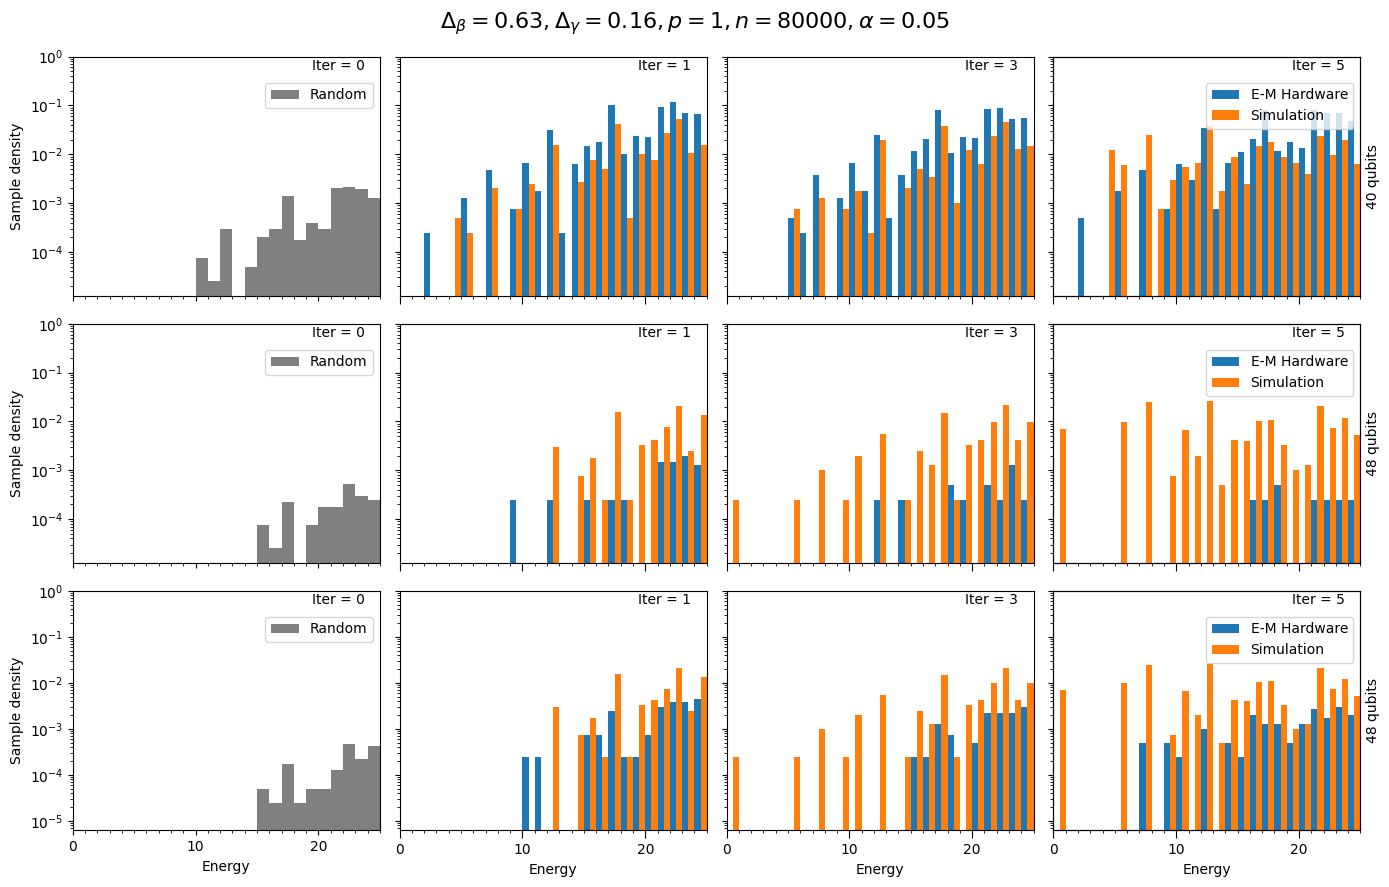

In [3]:
delta_b_fixed = 0.63
delta_g_fixed = 0.16
rescale = 10**(0.0)

n = 80000
iters=range(0,5,2)
max_beta_T = 0.15
eps = 0.15
alpha = 0.05
p = 1
# ENERGIES ** 2

fig, axs = plt.subplots(3, len(iters) + 1, sharey='row', sharex='col')
axs0 = axs[0, :]
axs1 = axs[1, :]
axs2 = axs[2, :]


compare_hardware_and_noiseless(axs0, 'test_N4_W5', (2*4)**-1, delta_b_fixed, delta_g_fixed, n, p, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, error_mitigation=True, backend="ibm_boston")
compare_hardware_and_noiseless(axs1, 'test_N4_W6', (2*4)**-1, delta_b_fixed, delta_g_fixed, n, p, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, error_mitigation=True, backend="ibm_boston")
compare_hardware_and_noiseless(axs2, 'test_N4_W6', (2*4)**-1, delta_b_fixed, delta_g_fixed, 2*n, p, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha/2, error_mitigation=True, backend="ibm_boston")


for ax in axs[:, 0]:
    ax.set_ylabel(r'Sample density')
    
qubits = [40, 48, 48]
for idx, ax in enumerate(axs[:, -1]):
    twin = ax.twinx()
    twin.set_yticks([])
    twin.set_ylabel(f'{qubits[idx]} qubits')
    
for ax in axs[-1, :]:  
    ax.set_xlabel(r'Energy')  
    
fig.suptitle(f'$\\Delta_\\beta = {delta_b_fixed}, \\Delta_\\gamma = {delta_g_fixed}, p = {p}, n = {n}, \\alpha = {alpha}$', fontsize=16)
fig.set_figheight(3 * len(axs[:, 0]))
fig.set_figwidth(3.5 * len(axs[0, :]))
plt.tight_layout()

In [27]:
(5 * 160000) / 2**48

2.8421709430404007e-09

In [8]:
filename='test_N4_W6'
error_mitigation=True
backend='ibm_boston'
# backend = None
simulation=False
n=80000
alpha=0.05
delta_b_fixed=0.63
delta_g_fixed=0.16

data_file = f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/qubo_data/qubo_data_{filename}.gfa.pkl'
_, hamiltonian, _, ising_offset = get_Q_and_hamiltonian(data_file)
num_qubits: int = hamiltonian.num_qubits

base_file_name = f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/nonvariational/hardware/hardware.{filename}'
append_str = (".simulation" if simulation else "")+ (".error_mit" if error_mitigation else "")+(f".backend{backend}" if backend else "") + (f'.db{delta_b_fixed}.dg{delta_g_fixed}.shots{n}') + (f'.betaT{max_beta_T}' if max_beta_T is not None else '') + (f'.eps{eps}' if eps is not None else '') + (f'.alpha{alpha}' if alpha is not None else '')
with open(f'{base_file_name}{append_str}.pkl', 'rb') as f:
    res = pickle.load(f)





In [11]:
samples = res['samples_dict'][(1,1)]
{i : {k: v/n for k,v in Counter([x.count('1') for x in samples[-1]]).items()}.get(i, 0) for i in range(num_qubits+1)}

{0: 0,
 1: 0,
 2: 0,
 3: 0,
 4: 3.75e-05,
 5: 0.0001,
 6: 0.0004375,
 7: 0.001075,
 8: 0.00235,
 9: 0.0050125,
 10: 0.00955,
 11: 0.0154625,
 12: 0.0238,
 13: 0.0341,
 14: 0.0432625,
 15: 0.0561125,
 16: 0.06545,
 17: 0.0754375,
 18: 0.082475,
 19: 0.0822875,
 20: 0.085675,
 21: 0.083775,
 22: 0.0767375,
 23: 0.066375,
 24: 0.05655,
 25: 0.044625,
 26: 0.033175,
 27: 0.0223625,
 28: 0.014175,
 29: 0.0095875,
 30: 0.0050625,
 31: 0.0026375,
 32: 0.001375,
 33: 0.0005375,
 34: 0.000275,
 35: 0.0001125,
 36: 1.25e-05,
 37: 0,
 38: 0,
 39: 0,
 40: 0,
 41: 0,
 42: 0,
 43: 0,
 44: 0,
 45: 0,
 46: 0,
 47: 0,
 48: 0}

In [21]:
samples_counter = Counter(samples[0])
evals = np.round(ising_offset + evaluate_sparse_pauli_samples(list(samples_counter.keys()), hamiltonian), 2)

sample_energies = []
sample_vals = []
for idx, (sample, count) in enumerate(samples_counter.items()):
    sample_energies.extend(count * [evals[idx]])
    sample_vals.extend(count * [sample])
sample_energies = np.array(sample_energies)
sample_vals = np.array(sample_vals)
idx = np.argsort(sample_energies)
quasi_energies = sample_energies[idx][:int(alpha * len(sample_vals))]
quasi_samples = sample_vals[idx][:int(alpha * len(sample_vals))]


In [23]:
quasi_energies[:20]

array([ 9., 12., 15., 17., 18., 21., 21., 21., 21., 21., 21., 22., 22.,
       22., 22., 22., 22., 23., 23., 23.])

In [22]:
{i : {k: v/(n*alpha) for k,v in Counter([x.count('1') for x in quasi_samples]).items()}.get(i, 0) for i in range(num_qubits+1)}

{0: 0,
 1: 0,
 2: 0.00025,
 3: 0.0015,
 4: 0.00925,
 5: 0.02675,
 6: 0.0845,
 7: 0.157,
 8: 0.23775,
 9: 0.25575,
 10: 0.18,
 11: 0.045,
 12: 0.00225,
 13: 0,
 14: 0,
 15: 0,
 16: 0,
 17: 0,
 18: 0,
 19: 0,
 20: 0,
 21: 0,
 22: 0,
 23: 0,
 24: 0,
 25: 0,
 26: 0,
 27: 0,
 28: 0,
 29: 0,
 30: 0,
 31: 0,
 32: 0,
 33: 0,
 34: 0,
 35: 0,
 36: 0,
 37: 0,
 38: 0,
 39: 0,
 40: 0,
 41: 0,
 42: 0,
 43: 0,
 44: 0,
 45: 0,
 46: 0,
 47: 0,
 48: 0}

In [ ]:
filename='trivial'
delta_b_fixed=1.0
delta_g_fixed=0.06

n=4000
alpha=1.0
data_file = f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/qubo_data/qubo_data_{filename}.gfa.pkl'
_, hamiltonian, _, ising_offset = get_Q_and_hamiltonian(data_file)
num_qubits: int = hamiltonian.num_qubits

base_file_name = f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/nonvariational/nonvariational.{filename}.db{delta_b_fixed}.dg{delta_g_fixed}.shots{int(n)}'
append_str = (f'.betaT{max_beta_T}' if max_beta_T is not None else '') + (f'.eps{eps}' if eps is not None else '') + (f'.alpha1.0' if alpha is not None else '')
with open(f'{base_file_name}{append_str}.pkl', 'rb') as f:
    simulation_res = pickle.load(f)
samples = simulation_res['samples_dict'][(1,1)]
{i : {k: v/n for k,v in Counter([x.count('1') for x in samples[-1]]).items()}.get(i,0) for i in range(num_qubits+1)}

In [ ]:
from scipy.stats import binom
B = binom(num_qubits, 1/(2*3))
{i: B.pmf(i) for i in range(num_qubits+1)}

In [ ]:
filename='test_N4_W5'
error_mitigation=True
backend='ibm_boston'
data_file = f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/qubo_data/qubo_data_{filename}.gfa.pkl'
_, hamiltonian, _, ising_offset = get_Q_and_hamiltonian(data_file)
num_qubits: int = hamiltonian.num_qubits

base_file_name = f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/nonvariational/hardware/hardware.{filename}'
append_str = (".error_mit" if error_mitigation else "")+(f".backend{backend}" if backend else "") + (f'.db{delta_b_fixed}.dg{delta_g_fixed}.shots{n}') + (f'.betaT{max_beta_T}' if max_beta_T is not None else '') + (f'.eps{eps}' if eps is not None else '') + (f'.alpha{alpha}' if alpha is not None else '')
with open(f'{base_file_name}{append_str}.pkl', 'rb') as f:
    res = pickle.load(f)

In [ ]:
samples = res['samples_dict'][(1,1)]

In [ ]:
base_file_name = f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/nonvariational/nonvariational.{filename}.db{delta_b_fixed}.dg{delta_g_fixed}.shots{int(n*alpha)}'
append_str = (f'.betaT{max_beta_T}' if max_beta_T is not None else '') + (f'.eps{eps}' if eps is not None else '') + (f'.alpha1.0' if alpha is not None else '')
with open(f'{base_file_name}{append_str}.pkl', 'rb') as f:
    simulation_res = pickle.load(f)

In [ ]:
sim_samples = simulation_res['samples_dict'][(1,1)]

In [ ]:
delta_b_fixed = 0.63
delta_g_fixed = 0.16
rescale = 10**(0.0)

iters=range(0,10,2)
max_beta_T = 0.15
eps = 0.15
p = 1
# ENERGIES ** 2

fig, axs = plt.subplots(2, len(iters) + 1, sharey='row', sharex='col')
axs0 = axs[0, :]
axs1 = axs[1, :]
# axs2 = axs[2, :]
# axs3 = axs[3, :]
# axs4 = axs[4, :]

compare_hardware_and_noiseless(axs0, 'trivial', (2*3)**-1, delta_b_fixed, delta_g_fixed, 40000, p, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=0.1, error_mitigation=True, backend="ibm_boston")
compare_hardware_and_noiseless(axs1, 'trivial', (2*3)**-1, delta_b_fixed, delta_g_fixed, 80000, p, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=0.05, error_mitigation=True, backend="ibm_boston")


for ax in axs[:, 0]:
    ax.set_ylabel(r'Sample density')
    
qubits = [18,18]
for idx, ax in enumerate(axs[:, -1]):
    twin = ax.twinx()
    twin.set_yticks([])
    twin.set_ylabel(f'{qubits[idx]} qubits')
    
for ax in axs[-1, :]:  
    ax.set_xlabel(r'Energy')  
    
fig.suptitle(f'$\\Delta_\\beta = {delta_b_fixed}, \\Delta_\\gamma = {delta_g_fixed}, p = {p}, n = 40,000, 80,000, \\alpha = 0.1,0.05$', fontsize=16)
fig.set_figheight(3 * len(axs[:, 0]))
fig.set_figwidth(3.5 * len(axs[0, :]))
plt.tight_layout()

In [ ]:
delta_b_fixed = 0.63
delta_g_fixed = 0.16
rescale = 10**(0.0)

n = 40000
iters=range(5)
max_beta_T = 0.15
eps = 0.15
alpha = 0.1
p = 3
# ENERGIES ** 2

fig, axs = plt.subplots(4, len(iters) + 1, sharey='row', sharex='col')
axs0 = axs[0, :]
axs1 = axs[1, :]
axs2 = axs[2, :]
axs3 = axs[3, :]
# axs4 = axs[4, :]

compare_hardware_and_noiseless(axs0, 'test_N2_W2', (2*2)**-1, delta_b_fixed, delta_g_fixed, n, p, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, error_mitigation=True)
compare_hardware_and_noiseless(axs1, 'trivial', (2*3)**-1, delta_b_fixed, delta_g_fixed, n, p, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, error_mitigation=True, backend="ibm_boston")
compare_hardware_and_noiseless(axs2, 'test_N3_W4', (2*3)**-1, delta_b_fixed, delta_g_fixed, n, p, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, error_mitigation=True, backend="ibm_boston")
compare_hardware_and_noiseless(axs3, 'test_N4_W5', (2*4)**-1, delta_b_fixed, delta_g_fixed, n, p, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, error_mitigation=True, backend="ibm_boston")



for ax in axs[:, 0]:
    ax.set_ylabel(r'Sample density')
    
qubits = [8,18, 24]
for idx, ax in enumerate(axs[:, -1]):
    twin = ax.twinx()
    twin.set_yticks([])
    twin.set_ylabel(f'{qubits[idx]} qubits')
    
for ax in axs[-1, :]:  
    ax.set_xlabel(r'Energy')  
    
fig.suptitle(f'$\\Delta_\\beta = {delta_b_fixed}, \\Delta_\\gamma = {delta_g_fixed}, p = {p}, n = {n}, \\alpha = {alpha}$', fontsize=16)
fig.set_figheight(3 * len(axs[:, 0]))
fig.set_figwidth(3.5 * len(axs[0, :]))
plt.tight_layout()

1 [('1000000000010000000001000000000100100000', 3), ('0100000000000001001000000000000100100000', 3)]
1 [('0000100000010000000000100000100000010000', 50), ('0000100000010000000000100000100000000001', 25)]


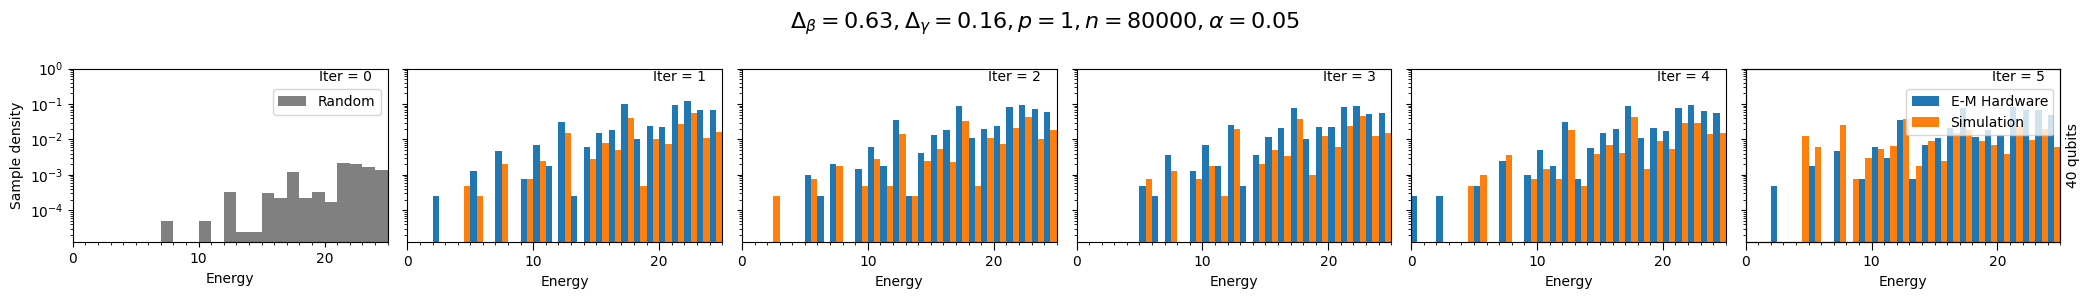

In [3]:
delta_b_fixed = 0.63
delta_g_fixed = 0.16
rescale = 10**(0.0)

n = 80000
iters=range(5)
max_beta_T = 0.15
eps = 0.15
alpha = 0.05
p = 1
# ENERGIES ** 2

fig, axs = plt.subplots(1, len(iters) + 1, sharey='row', sharex='col')
axs = np.asarray(axs).reshape((1, len(iters) + 1))
axs0 = axs[0, :]
# axs1 = axs[1, :]
# axs2 = axs[2, :]
# axs3 = axs[3, :]
# axs4 = axs[4, :]

# compare_hardware_and_noiseless(axs0, 'test_N2_W2', (2*2)**-1, delta_b_fixed, delta_g_fixed, n, p, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, error_mitigation=True)
# compare_hardware_and_noiseless(axs1, 'trivial', (2*3)**-1, delta_b_fixed, delta_g_fixed, n, p, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, error_mitigation=True, backend="ibm_boston")
# compare_hardware_and_noiseless(axs2, 'test_N3_W4', (2*3)**-1, delta_b_fixed, delta_g_fixed, n, p, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, error_mitigation=True, backend="ibm_boston")
compare_hardware_and_noiseless(axs0, 'test_N4_W5', (2*4)**-1, delta_b_fixed, delta_g_fixed, n, p, rescale=rescale, max_beta_T=max_beta_T, iters=iters, eps=eps, alpha=alpha, error_mitigation=True, backend="ibm_boston")


for ax in axs[:, 0]:
    ax.set_ylabel(r'Sample density')
    
qubits = [40]
for idx, ax in enumerate(axs[:, -1]):
    twin = ax.twinx()
    twin.set_yticks([])
    twin.set_ylabel(f'{qubits[idx]} qubits')
    
for ax in axs[-1, :]:  
    ax.set_xlabel(r'Energy')  
    
fig.suptitle(f'$\\Delta_\\beta = {delta_b_fixed}, \\Delta_\\gamma = {delta_g_fixed}, p = {p}, n = {n}, \\alpha = {alpha}$', fontsize=16)
fig.set_figheight(3 * len(axs[:, 0]))
fig.set_figwidth(3.5 * len(axs[0, :]))
plt.tight_layout()

In [ ]:
filename = 'test_N4_W5'
error_mitigation=True
backend='ibm_boston'
base_file_name = f'/lustre/scratch127/qpg/jc59/new_qubo_formulation/oriented/nonvariational/hardware/hardware.{filename}'
append_str = (".error_mit" if error_mitigation else "")+(f".backend{backend}" if backend else "") + (f'.db{delta_b_fixed}.dg{delta_g_fixed}.shots{n}') + (f'.betaT{max_beta_T}' if max_beta_T is not None else '') + (f'.eps{eps}' if eps is not None else '') + (f'.alpha{alpha}' if alpha is not None else '')
with open(f'{base_file_name}{append_str}.pkl', 'rb') as f:
    res = pickle.load(f)

In [ ]:
res.keys()

In [ ]:
res['samples_dict'].keys()